In [ ]:
print('je')

je


In [ ]:
!nvidia-smi

Tue Apr 21 12:00:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the package to lable the images & it will automatically lable all the images



img = image.load_img('/content/drive/MyDrive/cnn/cnn/training/happy/IMG_20240702_162446.jpg')

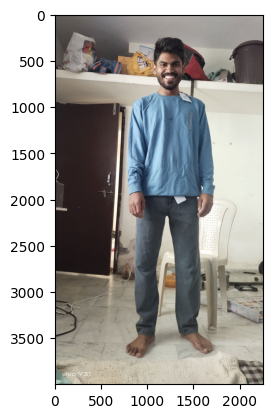

In [ ]:
plt.imshow(img)

In [ ]:
i1 = cv2.imread('/content/drive/MyDrive/cnn/cnn/training/happy/IMG_20240702_162446.jpg')
i1

array([[[ 84,  87,  92],
        [ 86,  89,  94],
        [ 88,  91,  96],
        ...,
        [161, 162, 166],
        [165, 166, 170],
        [164, 165, 169]],

       [[ 89,  92,  97],
        [ 89,  92,  97],
        [ 95,  98, 103],
        ...,
        [168, 169, 173],
        [170, 171, 175],
        [168, 169, 173]],

       [[100, 103, 108],
        [ 93,  96, 101],
        [ 91,  94,  99],
        ...,
        [170, 171, 175],
        [169, 170, 174],
        [167, 168, 172]],

       ...,

       [[137, 149, 131],
        [142, 154, 136],
        [148, 160, 142],
        ...,
        [144, 157, 155],
        [140, 153, 151],
        [141, 154, 152]],

       [[135, 147, 129],
        [143, 155, 137],
        [151, 163, 145],
        ...,
        [142, 155, 153],
        [138, 151, 149],
        [137, 150, 148]],

       [[138, 150, 132],
        [148, 160, 142],
        [150, 162, 144],
        ...,
        [147, 160, 158],
        [143, 156, 154],
        [140, 153, 151]]

In [ ]:
i1.shape

(4000, 2256, 3)

In [ ]:
train=ImageDataGenerator(rescale=1/200)
validation=ImageDataGenerator(rescale=1/200)

In [ ]:
train_dataset=train.flow_from_directory('/content/drive/MyDrive/cnn/cnn/training',
                                       target_size=(200,200),batch_size=32,class_mode='binary')
validation_dataset=train.flow_from_directory('/content/drive/MyDrive/cnn/cnn/validation',
                                       target_size=(200,200),batch_size=32,class_mode='binary')

Found 31 images belonging to 2 classes.
Found 0 images belonging to 3 classes.


In [ ]:
train_dataset.class_indices

{'happy': 0, 'nothappy': 1}

In [ ]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
# now we are applying maxpooling

model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filtr we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam())

In [ ]:
model_fit=model.fit(train_dataset,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.7083
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - loss: 6.5310
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step - loss: 2.3398
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step - loss: 0.6729
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step - loss: 0.7237
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step - loss: 0.3796
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step - loss: 0.5038
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step - loss: 0.3468
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step - loss: 0.2710
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - loss: 0.2640


In [ ]:
dir_path='/content/drive/MyDrive/cnn/cnn/testing'
for i in os.listdir(dir_path):
  print(i)

Snapchat-1459047724.jpg
Snapchat-1374747653.jpg
Snapchat-568508956.jpg
Snapchat-591257952.jpg
Snapchat-544430746.jpg
Snapchat-529833306.jpg
IMG_20240702_162626.jpg
IMG_20240702_162553.jpg
IMG_20240702_162446.jpg
IMG_20240702_162653.jpg


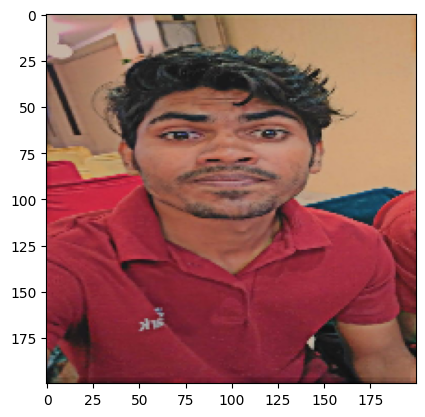

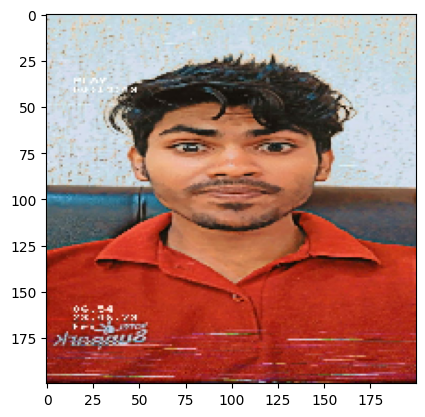

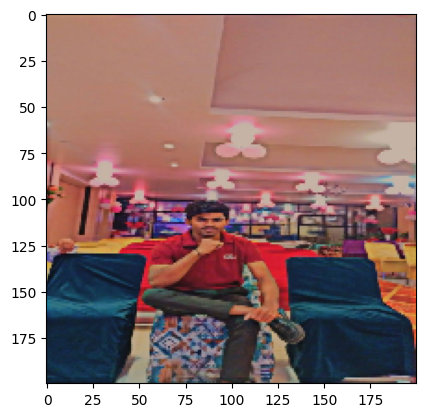

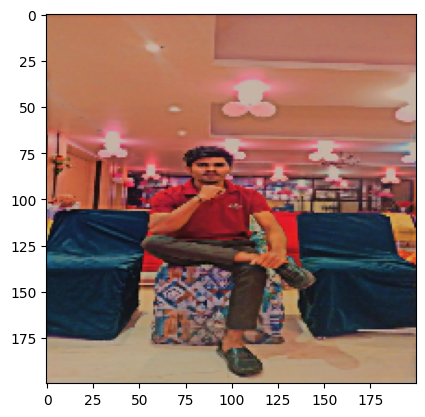

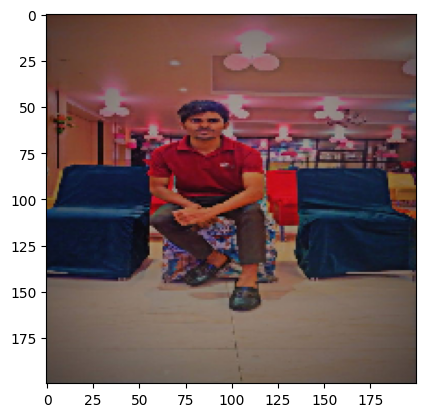

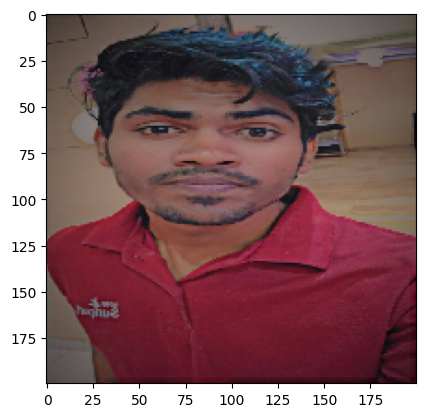

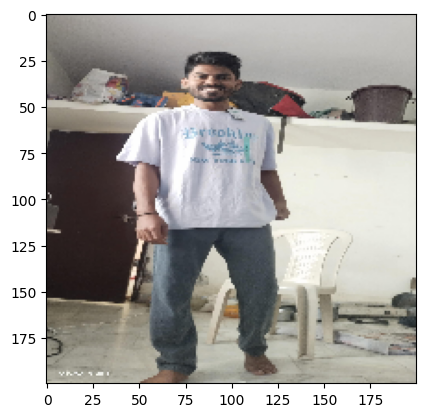

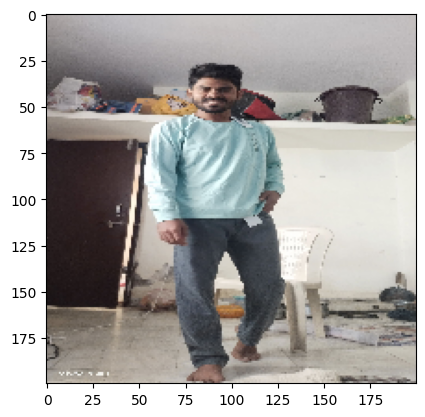

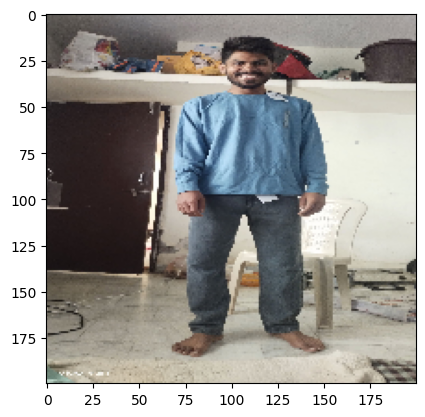

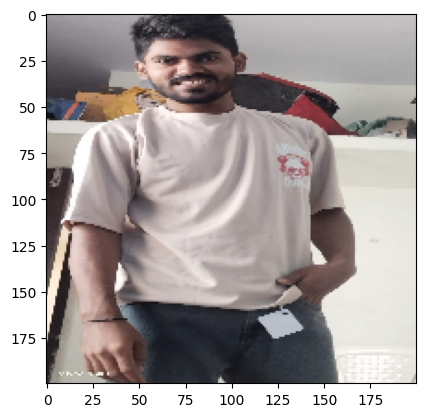

In [ ]:
dir_path = '/content/drive/MyDrive/cnn/cnn/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

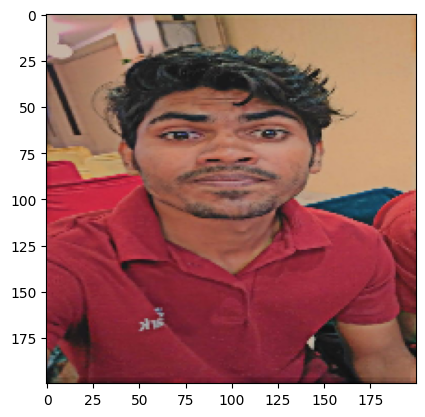

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
i am not happy


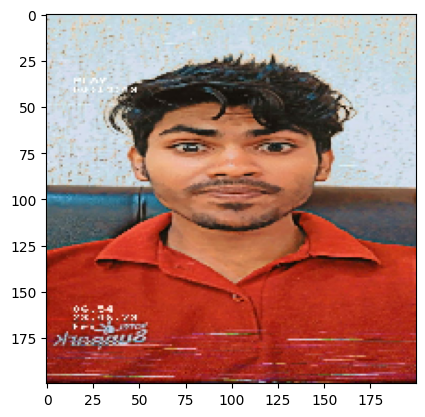

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
i am not happy


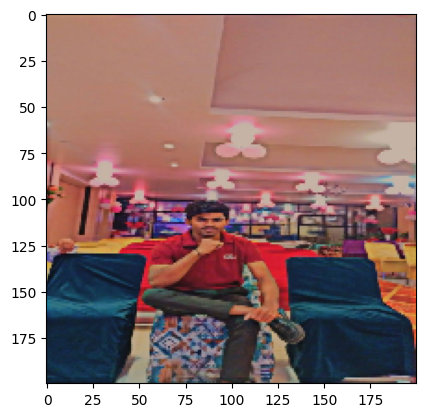

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
i am not happy


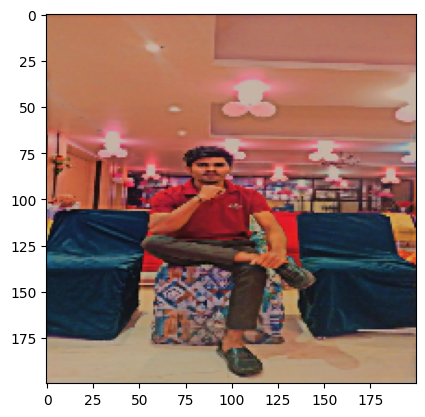

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
i am not happy


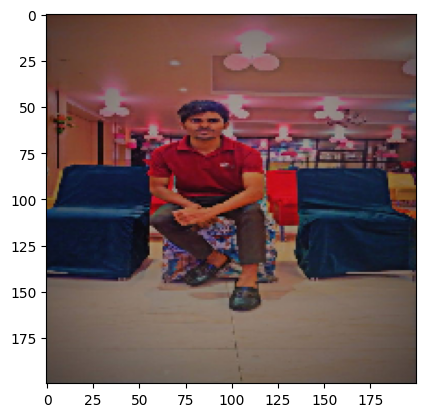

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
i am not happy


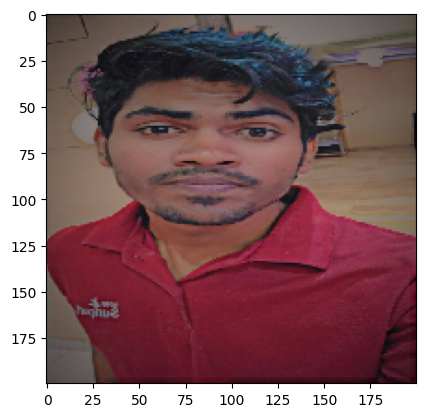

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
i am not happy


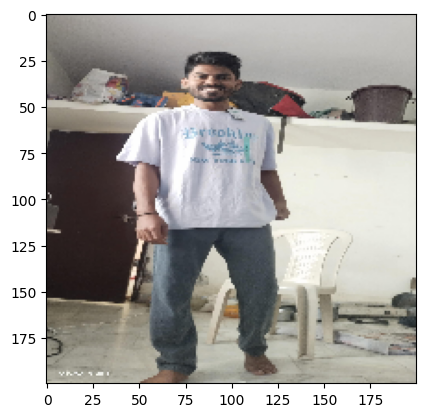

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
i am happy


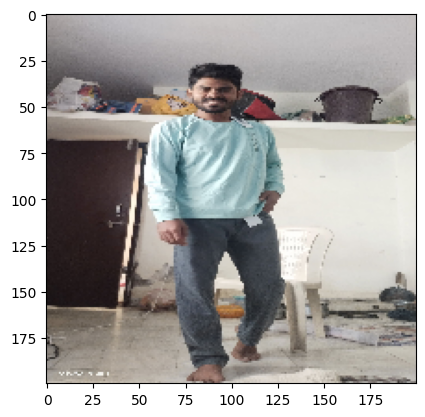

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
i am happy


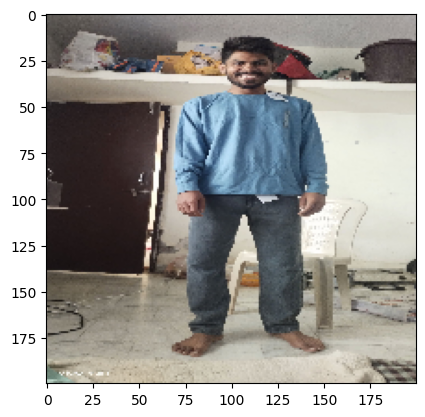

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
i am happy


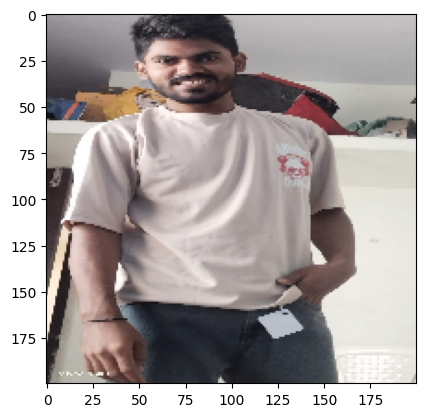

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
i am happy


In [ ]:

for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val == 0:
        print( 'i am happy')
    else:
        print('i am not happy')

In [ ]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
    # Resize the image to (200, 200) as expected by the model
    img = image.resize((200, 200))
    # Convert the image to a numpy array
    x = np.array(img)
    # Expand dimensions to create a batch of 1 image
    x = np.expand_dims(x, axis=0)
    # Normalize the image (if the model was trained with normalized inputs)
    # The model was trained with rescale=1/200, so we should apply the same scaling here.
    x = x / 200.0
    # Make prediction
    val = model.predict(x)[0][0]
    # Interpret the prediction
    if val < 0.5:
        return 'Happy'
    else:
        return 'Not Happy'

In [ ]:
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil", label="Upload an image"),
                     outputs=gr.Text(label="Predicted Mood"),
                     title="Mood Classification (Happy/Not Happy)",
                     description="Upload an image to classify if the person is happy or not happy.")

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://95fa1d2355149e5c9d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
